## 3.1 — Why Visualise Data?

> 📊 A table of 852 rows is hard to understand.
> 📈 One chart can tell the same story in seconds.

| Chart Type | Best For | World Cup Example |
|------------|----------|-------------------|
| **Line** | Trends over time | Goals per World Cup year |
| **Bar** | Comparing categories | Top 10 goal-scoring nations |
| **Horizontal Bar** | Long category names | Stadium attendance ranking |
| **Pie** | Parts of a whole | Match results breakdown |
| **Scatter** | Relationship between 2 things | Attendance vs Goals |
| **Histogram** | Spread of values | Distribution of match scores |

In [1]:
# ── Setup: load & prepare the dataset (recap from Pandas part) ──
import pandas as pd

df = pd.read_csv("WorldCupMatches.csv")
df = df.dropna(subset=["Year", "Home Team Name", "Home Team Goals", "Away Team Goals"])

df["Year"]            = df["Year"].astype(int)
df["Home Team Goals"] = df["Home Team Goals"].astype(int)
df["Away Team Goals"] = df["Away Team Goals"].astype(int)
df["Attendance"]      = pd.to_numeric(df["Attendance"], errors="coerce")

df["Home Team Name"] = df["Home Team Name"].str.strip()
df["Away Team Name"] = df["Away Team Name"].str.strip()

df["Total Goals"] = df["Home Team Goals"] + df["Away Team Goals"]
df["Goal Diff"]   = df["Home Team Goals"] - df["Away Team Goals"]
df["Home Result"] = df["Goal Diff"].apply(
    lambda x: "Win" if x > 0 else ("Draw" if x == 0 else "Loss")
)

print(f"✔ Dataset ready: {df.shape[0]} matches, {df.shape[1]} columns")


✔ Dataset ready: 852 matches, 23 columns


In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["font.family"]   = "DejaVu Sans"

print("Matplotlib ready! ✔")

Matplotlib ready! ✔


In [6]:
import pandas as pd
import numpy as np

# ── Load and clean the dataset ──
df = pd.read_csv("cleaned_data.csv")


## 3.2 — Line Chart: Goals per World Cup (1930–2014)

*Has the World Cup become more or less exciting over the decades?*

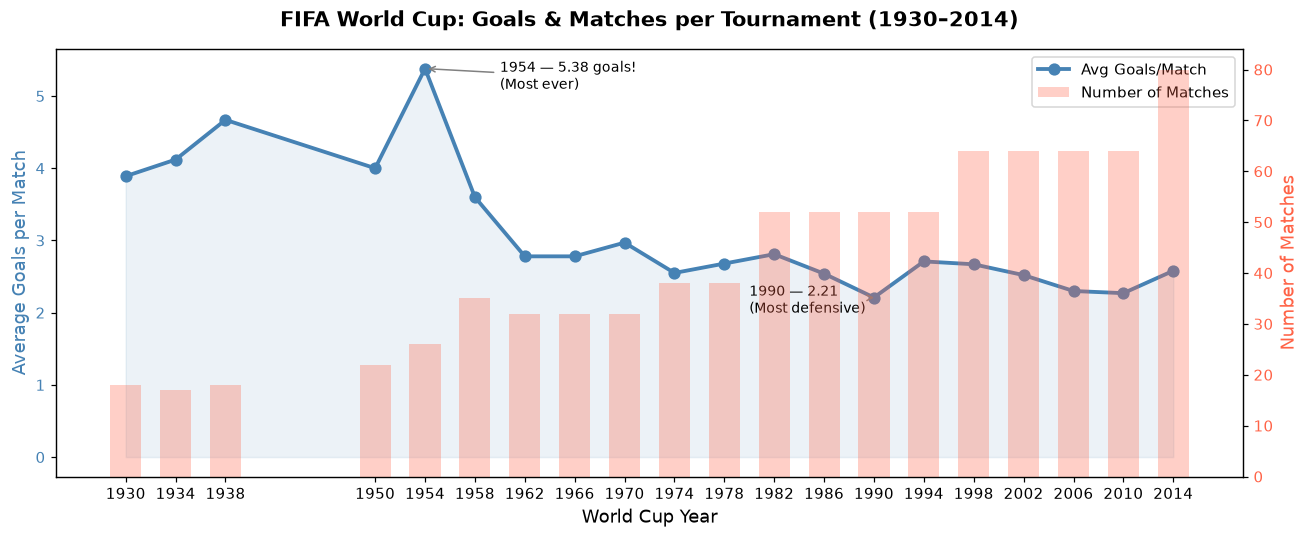

In [7]:
yearly = df.groupby("Year").agg(
    Matches     = ("Total Goals", "count"),
    Total_Goals = ("Total Goals", "sum"),
).reset_index()
yearly["Avg Goals"] = (yearly["Total_Goals"] / yearly["Matches"]).round(2)

fig, ax1 = plt.subplots(figsize=(12, 5))

# ── Line 1: Average goals per match ──
color1 = "steelblue"
ax1.plot(yearly["Year"], yearly["Avg Goals"],
         color=color1, linewidth=2.5, marker="o", markersize=7, label="Avg Goals/Match")
ax1.fill_between(yearly["Year"], yearly["Avg Goals"], alpha=0.1, color=color1)
ax1.set_xlabel("World Cup Year", fontsize=12)
ax1.set_ylabel("Average Goals per Match", fontsize=12, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

# ── Line 2: Total matches on a second y-axis ──
ax2 = ax1.twinx()
color2 = "tomato"
ax2.bar(yearly["Year"], yearly["Matches"], width=2.5,
        alpha=0.3, color=color2, label="Number of Matches")
ax2.set_ylabel("Number of Matches", fontsize=12, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

# Annotations for key moments
ax1.annotate("1954 — 5.38 goals!\n(Most ever)", xy=(1954, 5.38),
             xytext=(1960, 5.1), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="gray"))
ax1.annotate("1990 — 2.21\n(Most defensive)", xy=(1990, 2.21),
             xytext=(1980, 2.0), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="gray"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("FIFA World Cup: Goals & Matches per Tournament (1930–2014)",
          fontsize=14, fontweight="bold", pad=15)
plt.xticks(yearly["Year"], rotation=45)
plt.tight_layout()
plt.show()

## 3.3 — Horizontal Bar Chart: Top 15 Goal-Scoring Nations

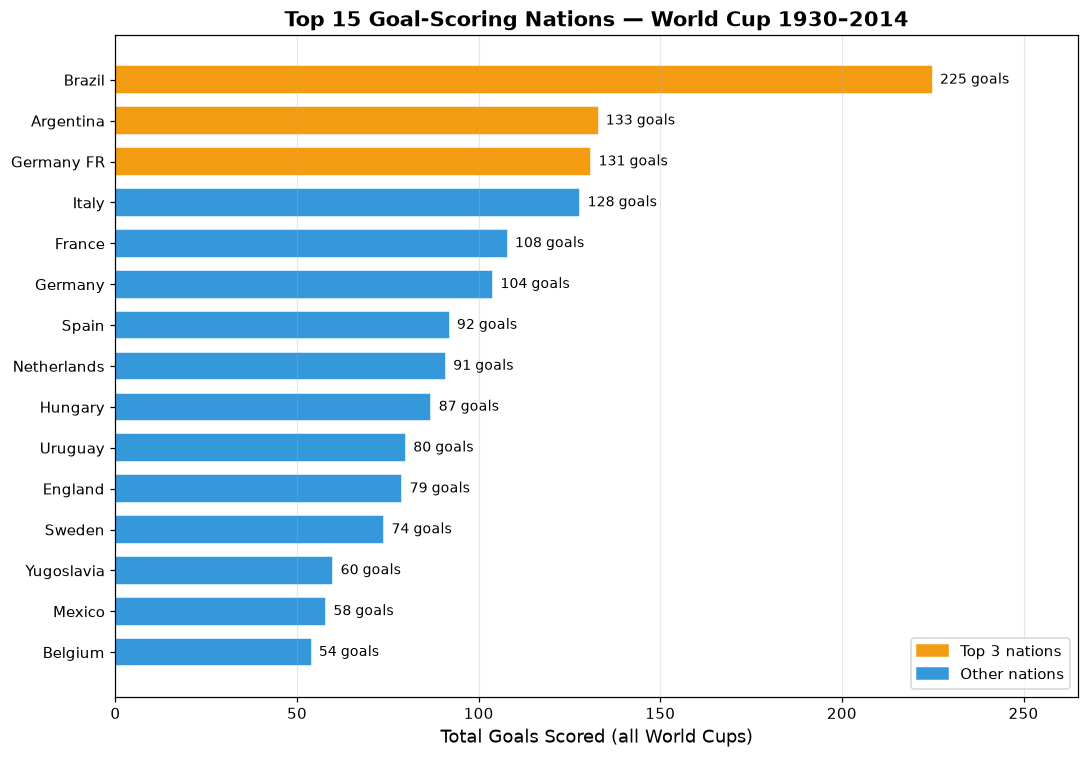

In [8]:
# Recalculate top scorers
home_scored = df.groupby("Home Team Name")["Home Team Goals"].sum()
away_scored = df.groupby("Away Team Name")["Away Team Goals"].sum()
top_scorers = home_scored.add(away_scored, fill_value=0).sort_values().tail(15)

fig, ax = plt.subplots(figsize=(10, 7))

# Colour the top 3 differently
colors = ["#f39c12" if i >= 12 else "#3498db" for i in range(15)]
bars = ax.barh(top_scorers.index, top_scorers.values, color=colors,
               edgecolor="white", height=0.7)

# Labels at end of each bar
for bar, val in zip(bars, top_scorers.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"{int(val)} goals", va="center", fontsize=9)

gold   = mpatches.Patch(color="#f39c12", label="Top 3 nations")
blue   = mpatches.Patch(color="#3498db", label="Other nations")
ax.legend(handles=[gold, blue])

ax.set_xlabel("Total Goals Scored (all World Cups)", fontsize=12)
ax.set_title("Top 15 Goal-Scoring Nations — World Cup 1930–2014",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, top_scorers.max() + 40)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 — Pie Chart: Match Result Breakdown

*How often does the home team win, draw, or lose?*

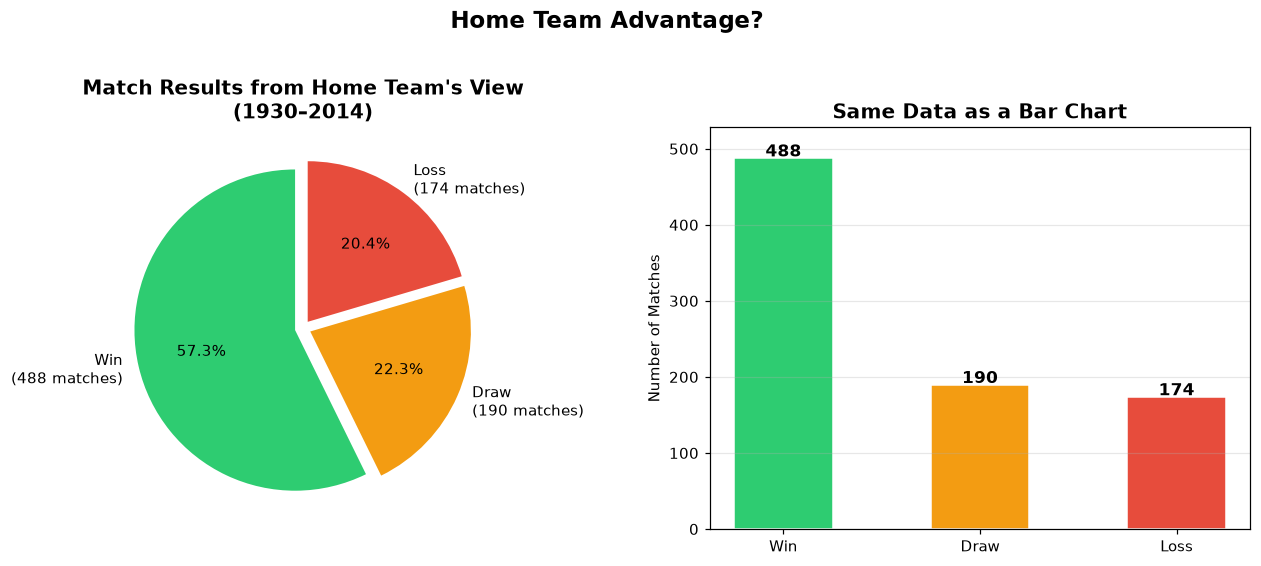

Home teams win 57.3% of World Cup matches — is there a home advantage?


In [9]:
result_counts = df["Home Result"].value_counts()

labels   = [f"{r}\n({c} matches)" for r, c in result_counts.items()]
colors   = ["#2ecc71", "#f39c12", "#e74c3c"]
explode  = (0.05, 0.05, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Pie chart ──
axes[0].pie(result_counts.values, labels=labels, colors=colors,
            explode=explode, autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 10})
axes[0].set_title("Match Results from Home Team's View\n(1930–2014)",
                  fontsize=13, fontweight="bold")

# ── Bar chart version of the same data (side by side for comparison) ──
bars = axes[1].bar(result_counts.index, result_counts.values,
                    color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, result_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2, str(val),
                 ha="center", fontweight="bold", fontsize=11)
axes[1].set_title("Same Data as a Bar Chart", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Matches")
axes[1].set_ylim(0, result_counts.max() + 40)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Home Team Advantage?", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

win_pct = result_counts["Win"] / result_counts.sum() * 100
print(f"Home teams win {win_pct:.1f}% of World Cup matches — is there a home advantage?")

## 3.5 — Scatter Plot: Does a Big Crowd Mean More Goals?

*Do players perform better (score more) in front of large crowds?*

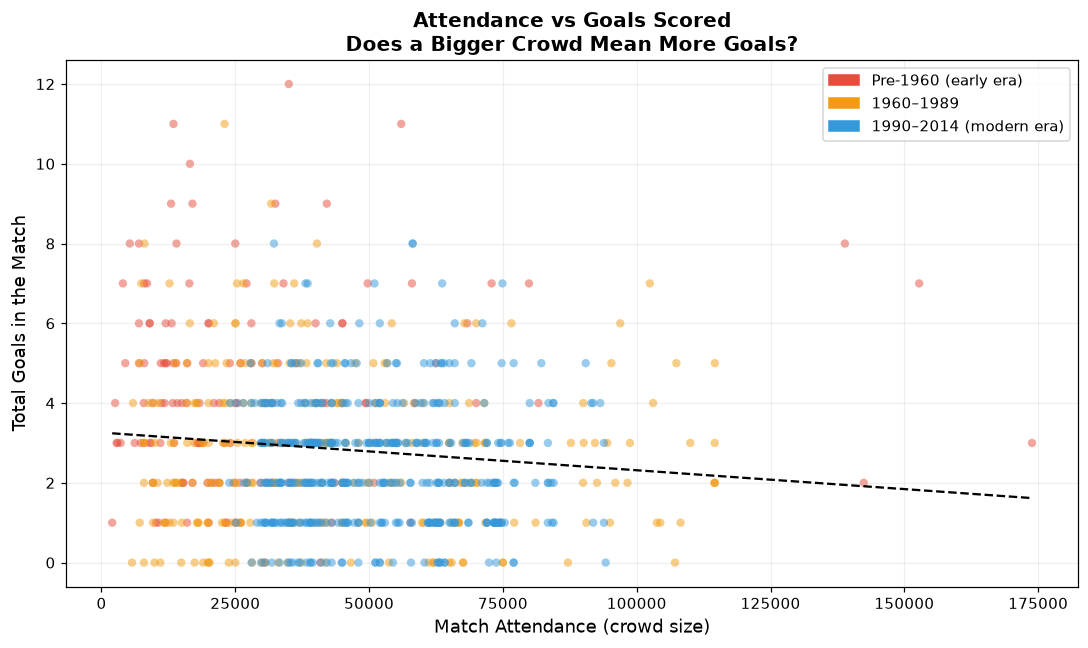

Correlation (attendance vs goals): -0.113
(0 = no relationship, 1 = perfect positive, -1 = perfect negative)


In [10]:
# Drop rows with missing attendance
scatter_df = df.dropna(subset=["Attendance"]).copy()

# Colour points by era
def era_color(year):
    if year < 1960:   return "#e74c3c"
    elif year < 1990: return "#f39c12"
    else:             return "#3498db"

point_colors = scatter_df["Year"].apply(era_color)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(scatter_df["Attendance"], scatter_df["Total Goals"],
           c=point_colors, alpha=0.5, s=30, edgecolors="none")

# Trend line
z = np.polyfit(scatter_df["Attendance"], scatter_df["Total Goals"], 1)
p = np.poly1d(z)
x_line = np.linspace(scatter_df["Attendance"].min(), scatter_df["Attendance"].max(), 200)
ax.plot(x_line, p(x_line), "k--", linewidth=1.5, label="Trend line")

# Legend
red   = mpatches.Patch(color="#e74c3c", label="Pre-1960 (early era)")
orange= mpatches.Patch(color="#f39c12", label="1960–1989")
blue  = mpatches.Patch(color="#3498db", label="1990–2014 (modern era)")
ax.legend(handles=[red, orange, blue], loc="upper right")

ax.set_xlabel("Match Attendance (crowd size)", fontsize=12)
ax.set_ylabel("Total Goals in the Match", fontsize=12)
ax.set_title("Attendance vs Goals Scored\nDoes a Bigger Crowd Mean More Goals?",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Correlation coefficient
corr = np.corrcoef(scatter_df["Attendance"], scatter_df["Total Goals"])[0, 1]
print(f"Correlation (attendance vs goals): {corr:.3f}")
print("(0 = no relationship, 1 = perfect positive, -1 = perfect negative)")

## 3.6 — Histogram: How Are Match Scores Distributed?

*What's the most common scoreline at the World Cup?*

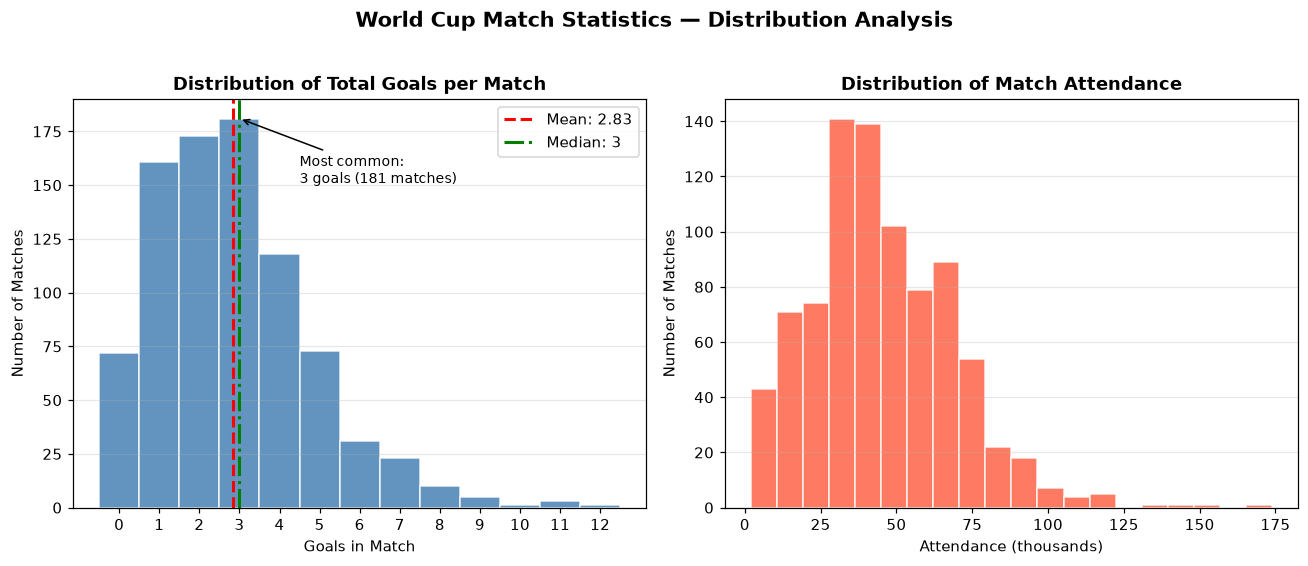

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Histogram of total goals per match ──
axes[0].hist(df["Total Goals"], bins=range(0, 14),
             color="steelblue", edgecolor="white", alpha=0.85, align="left")
axes[0].axvline(df["Total Goals"].mean(), color="red", linestyle="--",
                linewidth=2, label=f"Mean: {df['Total Goals'].mean():.2f}")
axes[0].axvline(df["Total Goals"].median(), color="green", linestyle="-.",
                linewidth=2, label=f"Median: {df['Total Goals'].median():.0f}")
axes[0].set_title("Distribution of Total Goals per Match",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Goals in Match")
axes[0].set_ylabel("Number of Matches")
axes[0].set_xticks(range(0, 13))
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Most common score annotation
mode_goals = df["Total Goals"].mode()[0]
mode_count = (df["Total Goals"] == mode_goals).sum()
axes[0].annotate(f"Most common:\n{int(mode_goals)} goals ({mode_count} matches)",
                 xy=(mode_goals, mode_count),
                 xytext=(mode_goals + 1.5, mode_count - 30), fontsize=9,
                 arrowprops=dict(arrowstyle="->"))

# ── Histogram of attendance ──
axes[1].hist(df["Attendance"].dropna() / 1000, bins=20,
             color="tomato", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribution of Match Attendance",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Attendance (thousands)")
axes[1].set_ylabel("Number of Matches")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("World Cup Match Statistics — Distribution Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3.7 — Subplots: The Complete World Cup Dashboard

C:\Users\HANIYA MAQSOOD\AppData\Local\Temp\ipykernel_16996\3059035510.py:71: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\HANIYA MAQSOOD\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


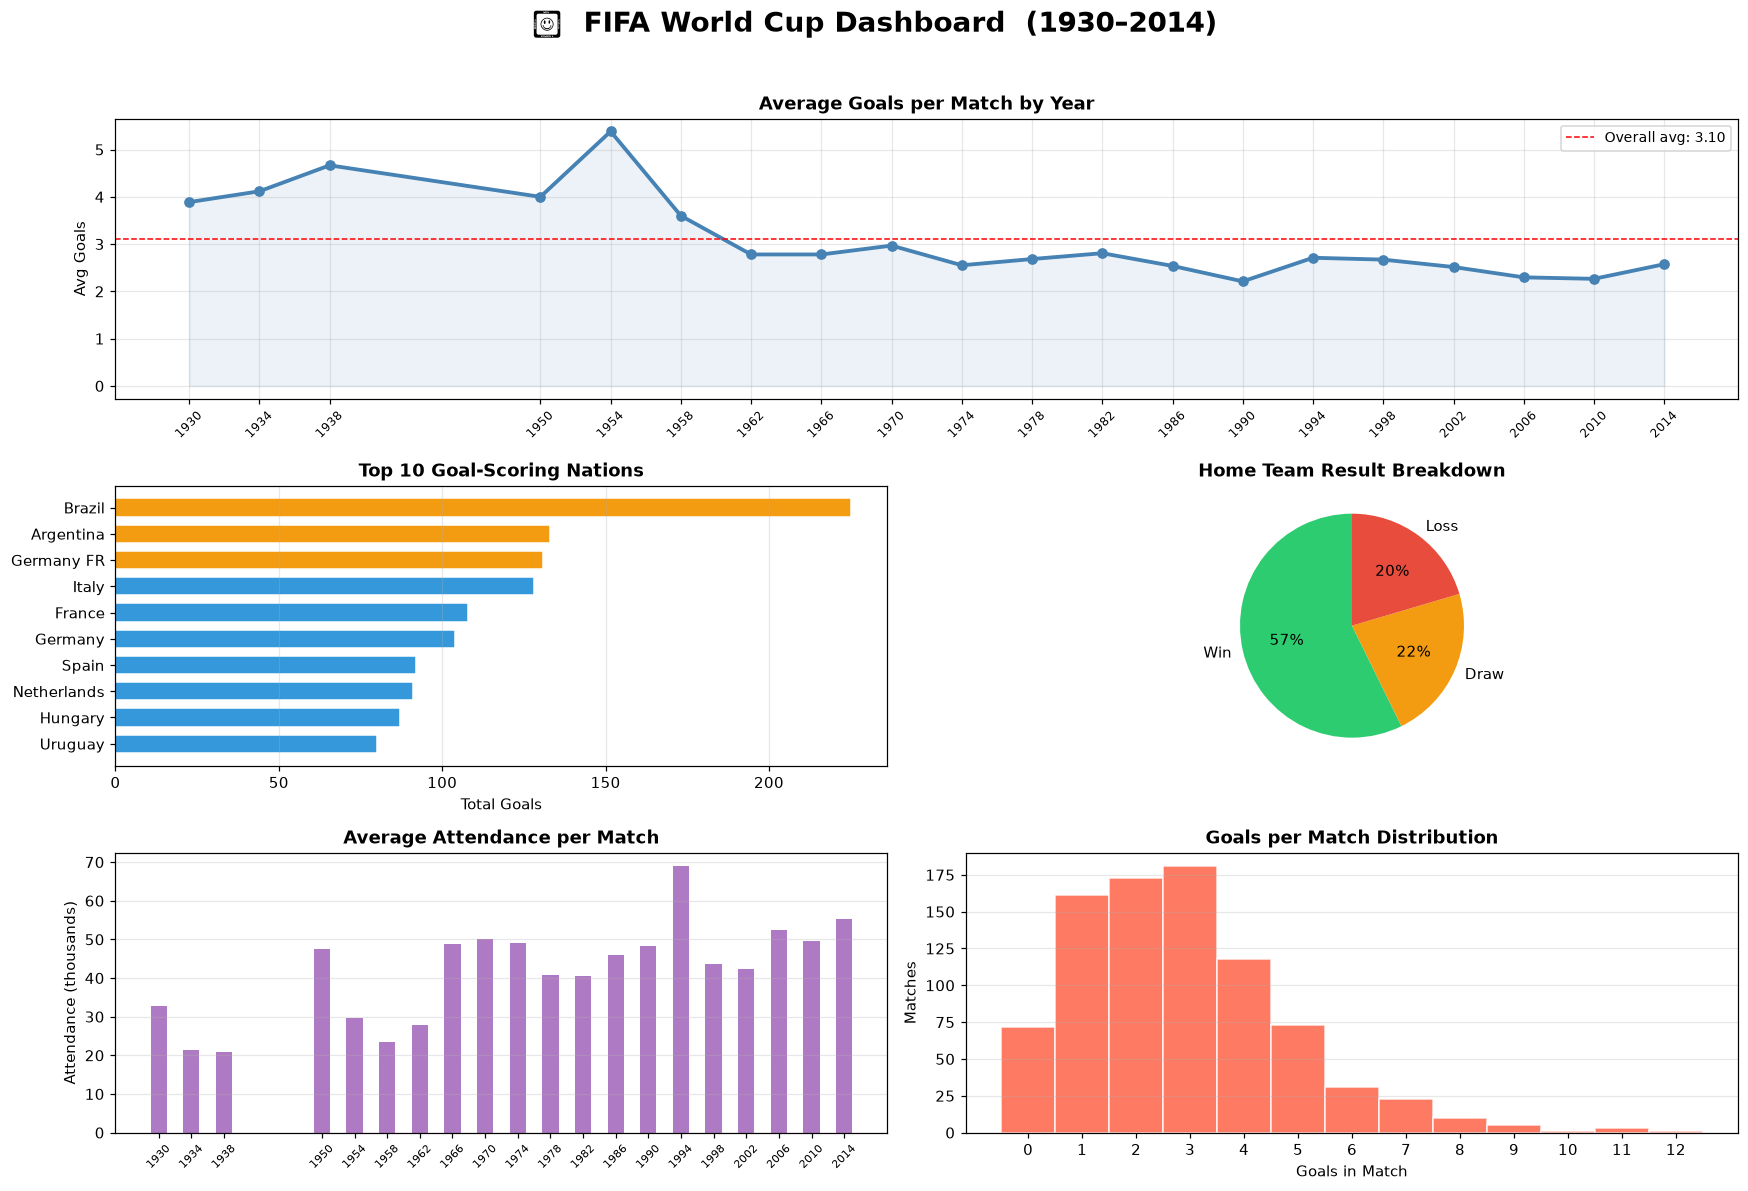

In [12]:
# ── Prepare all the data ──
yearly_stats = df.groupby("Year").agg(
    Matches    = ("MatchID",     "count"),
    Goals      = ("Total Goals", "sum"),
    Avg_Goals  = ("Total Goals", "mean"),
    Avg_Crowd  = ("Attendance",  "mean"),
).reset_index()

home_s = df.groupby("Home Team Name")["Home Team Goals"].sum()
away_s = df.groupby("Away Team Name")["Away Team Goals"].sum()
top10  = home_s.add(away_s, fill_value=0).sort_values(ascending=False).head(10)

result_counts = df["Home Result"].value_counts()

# ── Build the dashboard ──
fig = plt.figure(figsize=(16, 11))
fig.suptitle("⚽  FIFA World Cup Dashboard  (1930–2014)",
             fontsize=18, fontweight="bold", y=0.98)

# Panel 1 (top-left wide): Goals trend line
ax1 = fig.add_subplot(3, 2, (1, 2))   # spans both top columns
ax1.plot(yearly_stats["Year"], yearly_stats["Avg_Goals"],
         color="steelblue", linewidth=2.5, marker="o", markersize=6)
ax1.fill_between(yearly_stats["Year"], yearly_stats["Avg_Goals"], alpha=0.1, color="steelblue")
ax1.set_title("Average Goals per Match by Year", fontweight="bold")
ax1.set_ylabel("Avg Goals")
ax1.set_xticks(yearly_stats["Year"])
ax1.set_xticklabels(yearly_stats["Year"].astype(int), rotation=45, fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.axhline(yearly_stats["Avg_Goals"].mean(), color="red",
            linestyle="--", linewidth=1, label=f"Overall avg: {yearly_stats['Avg_Goals'].mean():.2f}")
ax1.legend(fontsize=9)

# Panel 2 (mid-left): Top 10 teams
ax2 = fig.add_subplot(3, 2, 3)
colors_bar = ["#f39c12"]*3 + ["#3498db"]*7
ax2.barh(top10.index, top10.values, color=colors_bar, edgecolor="white", height=0.7)
ax2.set_title("Top 10 Goal-Scoring Nations", fontweight="bold")
ax2.set_xlabel("Total Goals")
ax2.grid(axis="x", alpha=0.3)
ax2.invert_yaxis()

# Panel 3 (mid-right): Match results pie
ax3 = fig.add_subplot(3, 2, 4)
pie_cols = ["#2ecc71", "#f39c12", "#e74c3c"]
ax3.pie(result_counts.values, labels=result_counts.index,
        colors=pie_cols, autopct="%1.0f%%", startangle=90,
        textprops={"fontsize": 10})
ax3.set_title("Home Team Result Breakdown", fontweight="bold")

# Panel 4 (bottom-left): Attendance trend
ax4 = fig.add_subplot(3, 2, 5)
ax4.bar(yearly_stats["Year"], yearly_stats["Avg_Crowd"] / 1000,
        color="#9b59b6", alpha=0.8, width=2)
ax4.set_title("Average Attendance per Match", fontweight="bold")
ax4.set_ylabel("Attendance (thousands)")
ax4.set_xticks(yearly_stats["Year"])
ax4.set_xticklabels(yearly_stats["Year"].astype(int), rotation=45, fontsize=7)
ax4.grid(axis="y", alpha=0.3)

# Panel 5 (bottom-right): Goals distribution
ax5 = fig.add_subplot(3, 2, 6)
ax5.hist(df["Total Goals"], bins=range(0, 14), color="tomato",
         edgecolor="white", alpha=0.85, align="left")
ax5.set_title("Goals per Match Distribution", fontweight="bold")
ax5.set_xlabel("Goals in Match")
ax5.set_ylabel("Matches")
ax5.set_xticks(range(0, 13))
ax5.grid(axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## 🎯 10-MINUTE ACTIVITY — Hour 3
### *Build a Head-to-Head Battle Chart*

Pick any two World Cup rivals and visualise their history!
The code is ready — just change the team names.

---

In [13]:
# 🎯 ACTIVITY 3 — Head-to-Head Battle Visualiser
# Change these to any two teams in the dataset!
TEAM_A = "Brazil"
TEAM_B = "Italy"

# ── Find all matches between these two teams ──
h2h = df[
    ((df["Home Team Name"] == TEAM_A) & (df["Away Team Name"] == TEAM_B)) |
    ((df["Home Team Name"] == TEAM_B) & (df["Away Team Name"] == TEAM_A))
].copy()

if len(h2h) == 0:
    print(f"No matches found between {TEAM_A} and {TEAM_B}")
else:
    # Work out goals for each team in each match
    def goals_for(row, team):
        return row["Home Team Goals"] if row["Home Team Name"] == team else row["Away Team Goals"]

    h2h[f"{TEAM_A} Goals"] = h2h.apply(goals_for, team=TEAM_A, axis=1)
    h2h[f"{TEAM_B} Goals"] = h2h.apply(goals_for, team=TEAM_B, axis=1)
    h2h["Winner"] = h2h.apply(
        lambda r: TEAM_A if r[f"{TEAM_A} Goals"] > r[f"{TEAM_B} Goals"]
        else (TEAM_B if r[f"{TEAM_B} Goals"] > r[f"{TEAM_A} Goals"] else "Draw"), axis=1)

    # ── Summary stats ──
    a_wins  = (h2h["Winner"] == TEAM_A).sum()
    b_wins  = (h2h["Winner"] == TEAM_B).sum()
    draws   = (h2h["Winner"] == "Draw").sum()
    a_goals = h2h[f"{TEAM_A} Goals"].sum()
    b_goals = h2h[f"{TEAM_B} Goals"].sum()

    print(f"⚔️  {TEAM_A} vs {TEAM_B} — All World Cup Meetings")
    print("=" * 50)
    for _, r in h2h.iterrows():
        mark = "🏆" if r["Winner"] == TEAM_A else ("⚖️" if r["Winner"] == "Draw" else "  ")
        print(f"  {mark} {int(r['Year'])}  {TEAM_A} {int(r[f'{TEAM_A} Goals'])} - "
              f"{int(r[f'{TEAM_B} Goals'])} {TEAM_B}  [{r['Stage'].strip()}]")
    print("=" * 50)
    print(f"  {TEAM_A} wins : {a_wins} | Draws: {draws} | {TEAM_B} wins: {b_wins}")
    print(f"  Goals — {TEAM_A}: {int(a_goals)}  |  {TEAM_B}: {int(b_goals)}")

⚔️  Brazil vs Italy — All World Cup Meetings
     1938  Brazil 1 - 2 Italy  [Semi-finals]
  🏆 1970  Brazil 4 - 1 Italy  [Final]
  🏆 1978  Brazil 2 - 1 Italy  [Match for third place]
     1982  Brazil 2 - 3 Italy  [Group 3]
  ⚖️ 1994  Brazil 0 - 0 Italy  [Final]
  Brazil wins : 2 | Draws: 1 | Italy wins: 2
  Goals — Brazil: 9  |  Italy: 7


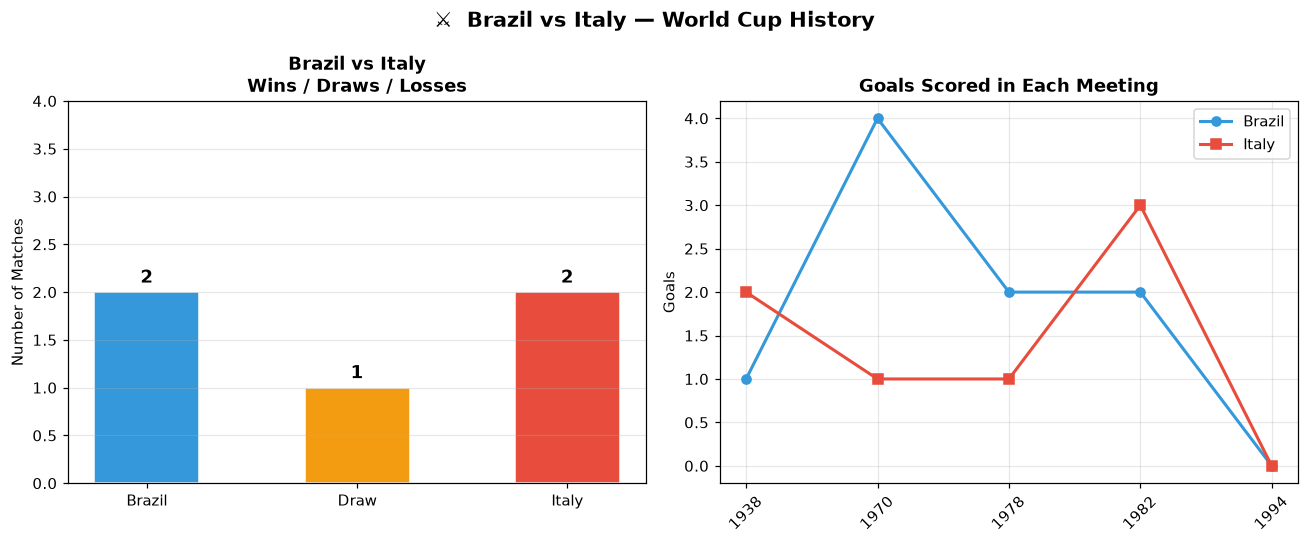

In [14]:
# ── Visualise the head-to-head ──
if len(h2h) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Bar: wins comparison
    col_a = "#3498db"
    col_b = "#e74c3c"

    axes[0].bar([TEAM_A, "Draw", TEAM_B], [a_wins, draws, b_wins],
                color=[col_a, "#f39c12", col_b], edgecolor="white", width=0.5)
    for i, val in enumerate([a_wins, draws, b_wins]):
        axes[0].text(i, val + 0.1, str(val), ha="center", fontweight="bold", fontsize=12)
    axes[0].set_title(f"{TEAM_A} vs {TEAM_B}\nWins / Draws / Losses", fontweight="bold")
    axes[0].set_ylabel("Number of Matches")
    axes[0].set_ylim(0, max(a_wins, b_wins, draws) + 2)
    axes[0].grid(axis="y", alpha=0.3)

    # Line: goals in each match over time
    x = range(len(h2h))
    labels = [str(int(y)) for y in h2h["Year"]]
    axes[1].plot(x, h2h[f"{TEAM_A} Goals"].values, color=col_a,
                 marker="o", linewidth=2, label=TEAM_A)
    axes[1].plot(x, h2h[f"{TEAM_B} Goals"].values, color=col_b,
                 marker="s", linewidth=2, label=TEAM_B)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=45)
    axes[1].set_title(f"Goals Scored in Each Meeting", fontweight="bold")
    axes[1].set_ylabel("Goals")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"⚔️  {TEAM_A} vs {TEAM_B} — World Cup History",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## 📝 Class Summary

| Library | What It Does | Key Skills Learned |
|---------|--------------|--------------------|
| **NumPy** | Fast number crunching | Arrays, math ops, filtering, stats by group |
| **Pandas** | Table/spreadsheet data | Load CSV, clean, filter, groupby, new columns |
| **Matplotlib** | Charts & visualisation | Line, bar, pie, scatter, histogram, dashboard |

---
## 🏠 Homework Exercises

1. **NumPy:** Find the World Cup year with the **lowest** average attendance. Which match in that year had the biggest crowd?

2. **Pandas:** Create a DataFrame showing only **Final matches**. Add a column `"Champion"` that shows which team won each final.

3. **Pandas:** Find all matches where **both teams scored at least 3 goals**. Which year had the most such matches?

4. **Matplotlib:** Plot a line chart comparing the **total goals per World Cup** for Brazil and Argentina over the years (one line per team).

5. **Challenge:** Build a **Stage Analysis** — group matches by Stage (Group, Quarter-final, Semi-final, Final) and plot the average goals per match for each stage. Do knockout games have fewer or more goals?

---
*Next Class → Data Cleaning, Merging DataFrames & Real Pipeline Projects* 🚀